In [42]:
import json
import time
import random
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DAILY_BUDGET = 1.00

ARTIFACT_DIR = Path("llm_cost_autopilot_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

print("Artifact directory:", ARTIFACT_DIR.resolve())

Artifact directory: /content/llm_cost_autopilot_artifacts


In [44]:
models = pd.DataFrame([
    {
        "model": "tiny",
        "quality": 1,
        "input_cost_per_million": 0.10,
        "output_cost_per_million": 0.40,
        "latency_ms": 150
    },
    {
        "model": "mini",
        "quality": 2,
        "input_cost_per_million": 0.50,
        "output_cost_per_million": 2.00,
        "latency_ms": 350
    },
    {
        "model": "standard",
        "quality": 3,
        "input_cost_per_million": 2.00,
        "output_cost_per_million": 8.00,
        "latency_ms": 700
    },
    {
        "model": "premium",
        "quality": 4,
        "input_cost_per_million": 8.00,
        "output_cost_per_million": 30.00,
        "latency_ms": 1400
    }
])

models

,model,quality,input_cost_per_million,output_cost_per_million,latency_ms
0,tiny,1,0.1,0.4,150
1,mini,2,0.5,2.0,350
2,standard,3,2.0,8.0,700
3,premium,4,8.0,30.0,1400


In [45]:
def estimate_tokens(text):
    if not isinstance(text, str):
        raise TypeError("Prompt must be a string.")

    text = text.strip()

    if not text:
        raise ValueError("Prompt cannot be empty.")

    return max(1, len(text) // 4)

In [46]:
def estimate_output_tokens(prompt):

    words = len(prompt.split())

    if words < 20:
        return 100

    if words < 60:
        return 250

    return 500

In [47]:
def detect_complexity(prompt):

    text = prompt.lower()

    hard_keywords = [
        "architecture",
        "debug",
        "analyze",
        "reason",
        "optimize",
        "algorithm",
        "mlops",
        "distributed",
        "security",
        "design system"
    ]

    medium_keywords = [
        "explain",
        "summarize",
        "compare",
        "rewrite",
        "classify",
        "extract"
    ]

    hard_hits = sum(
        keyword in text
        for keyword in hard_keywords
    )

    medium_hits = sum(
        keyword in text
        for keyword in medium_keywords
    )

    if hard_hits >= 1 or len(prompt) > 800:
        return "high"

    if medium_hits >= 1 or len(prompt) > 250:
        return "medium"

    return "low"

In [48]:
QUALITY_REQUIREMENTS = {
    "low": 1,
    "medium": 2,
    "high": 3
}

def required_quality(prompt):

    complexity = detect_complexity(prompt)

    return QUALITY_REQUIREMENTS[
        complexity
    ]

In [49]:
def calculate_cost(
    model,
    input_tokens,
    output_tokens
):

    input_cost = (
        input_tokens
        / 1_000_000
        * model["input_cost_per_million"]
    )

    output_cost = (
        output_tokens
        / 1_000_000
        * model["output_cost_per_million"]
    )

    return input_cost + output_cost

In [50]:
def model_cost_table(prompt):

    input_tokens = estimate_tokens(prompt)

    output_tokens = estimate_output_tokens(
        prompt
    )

    rows = []

    for _, model in models.iterrows():

        cost = calculate_cost(
            model,
            input_tokens,
            output_tokens
        )

        rows.append({
            "model": model["model"],
            "quality": model["quality"],
            "input_tokens": input_tokens,
            "output_tokens": output_tokens,
            "estimated_cost": cost
        })

    return pd.DataFrame(rows)

In [51]:
def route_request(prompt):

    complexity = detect_complexity(
        prompt
    )

    min_quality = QUALITY_REQUIREMENTS[
        complexity
    ]

    input_tokens = estimate_tokens(
        prompt
    )

    output_tokens = estimate_output_tokens(
        prompt
    )

    candidates = models[
        models["quality"] >= min_quality
    ].copy()

    candidates["estimated_cost"] = candidates.apply(
        lambda row: calculate_cost(
            row,
            input_tokens,
            output_tokens
        ),
        axis=1
    )

    selected = candidates.sort_values(
        "estimated_cost"
    ).iloc[0]

    return {
        "model": selected["model"],
        "complexity": complexity,
        "required_quality": min_quality,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "estimated_cost": float(
            selected["estimated_cost"]
        )
    }

In [52]:
spent_today = 0.0

In [53]:
def budget_route(prompt):

    route = route_request(
        prompt
    )

    remaining = budget_remaining()

    if route["estimated_cost"] > remaining:

        return {
            **route,
            "status": "BLOCKED_BUDGET",
            "remaining_budget": remaining
        }

    return {
        **route,
        "status": "APPROVED",
        "remaining_budget": remaining
    }

In [54]:
def mock_llm(model_name, prompt):

    model = models[
        models["model"] == model_name
    ].iloc[0]

    simulated_latency = (
        model["latency_ms"]
        / 1000
    )

    time.sleep(
        simulated_latency / 20
    )

    return (
        f"[Demo response from {model_name}] "
        f"Processed: {prompt[:80]}"
    )

In [55]:
request_logs = []

In [56]:
def llm_autopilot(prompt):

    global spent_today

    route = budget_route(
        prompt
    )

    timestamp = datetime.now(
        timezone.utc
    ).isoformat()

    if route["status"] == "BLOCKED_BUDGET":

        request_logs.append({
            "timestamp": timestamp,
            "prompt": prompt,
            **route
        })

        return {
            "status": "BLOCKED_BUDGET",
            "message":
                "Daily LLM budget exceeded."
        }

    start = time.perf_counter()

    response = mock_llm(
        route["model"],
        prompt
    )

    latency_ms = (
        time.perf_counter()
        - start
    ) * 1000

    spent_today += route[
        "estimated_cost"
    ]

    log = {
        "timestamp": timestamp,
        "prompt": prompt,
        "model": route["model"],
        "complexity": route["complexity"],
        "required_quality":
            route["required_quality"],
        "input_tokens":
            route["input_tokens"],
        "output_tokens":
            route["output_tokens"],
        "cost":
            route["estimated_cost"],
        "latency_ms":
            latency_ms,
        "status":
            "SUCCESS"
    }

    request_logs.append(log)

    return {
        "model":
            route["model"],
        "complexity":
            route["complexity"],
        "cost":
            route["estimated_cost"],
        "response":
            response
    }

In [57]:
def budget_remaining():
    return DAILY_BUDGET - spent_today

llm_autopilot(
    "What is Python?"
)

{'model': 'tiny',
 'complexity': 'low',
 'cost': 4.0300000000000004e-05,
 'response': '[Demo response from tiny] Processed: What is Python?'}

In [58]:
llm_autopilot(
    """
    Design an MLOps architecture for
    deploying and monitoring multiple
    machine learning models with rollback.
    """
)

{'model': 'standard',
 'complexity': 'high',
 'cost': 0.000856,
 'response': '[Demo response from standard] Processed: \n    Design an MLOps architecture for\n    deploying and monitoring multiple\n    '}

In [59]:
logs_df = pd.DataFrame(
    request_logs
)

logs_df

,timestamp,prompt,model,complexity,required_quality,input_tokens,output_tokens,cost,latency_ms,status
0,2026-09-27T00:28:40.118859+00:00,What is Python?,tiny,low,1,3,100,0.000040,8.759925,SUCCESS
1,2026-09-27T00:28:40.158777+00:00,\n Design an MLOps architecture for\n de...,standard,high,3,28,100,0.000856,39.483118,SUCCESS


In [60]:
demo_requests = [
    "What is SQL?",

    "Rewrite this sentence more clearly.",

    "Explain gradient descent.",

    "Summarize a machine learning article.",

    "Compare logistic regression and random forests.",

    "What does API mean?",

    "Explain model drift.",

    """
    Analyze an MLOps deployment architecture
    and identify possible failure points.
    """,

    """
    Design a distributed machine learning
    monitoring architecture with rollback.
    """,

    "What is a dataframe?"
]

In [61]:
logs_df = pd.DataFrame(
    request_logs
)

logs_df

,timestamp,prompt,model,complexity,required_quality,input_tokens,output_tokens,cost,latency_ms,status
0,2026-09-27T00:28:40.118859+00:00,What is Python?,tiny,low,1,3,100,0.000040,8.759925,SUCCESS
1,2026-09-27T00:28:40.158777+00:00,\n Design an MLOps architecture for\n de...,standard,high,3,28,100,0.000856,39.483118,SUCCESS


In [62]:
total_cost = logs_df[
    "cost"
].fillna(0).sum()

print(
    f"Total autopilot cost: ${total_cost:.6f}"
)

print(
    f"Remaining budget: ${budget_remaining():.6f}"
)

Total autopilot cost: $0.000896
Remaining budget: $0.999104


In [63]:
model_usage = (
    logs_df[
        logs_df["status"] == "SUCCESS"
    ]["model"]
    .value_counts()
)

model_usage

,count
model,
tiny,1
standard,1


In [64]:
cost_by_model = (
    logs_df[
        logs_df["status"] == "SUCCESS"
    ]
    .groupby("model")["cost"]
    .sum()
    .sort_values()
)

cost_by_model

,cost
model,
tiny,0.000040
standard,0.000856


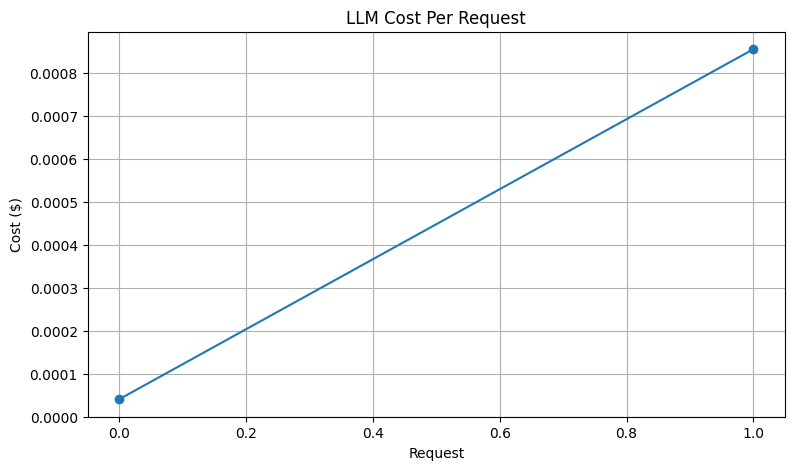

In [65]:
successful = logs_df[
    logs_df["status"] == "SUCCESS"
].reset_index(drop=True)

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    successful.index,
    successful["cost"],
    marker="o"
)

plt.xlabel(
    "Request"
)

plt.ylabel(
    "Cost ($)"
)

plt.title(
    "LLM Cost Per Request"
)

plt.grid(True)

plt.show()

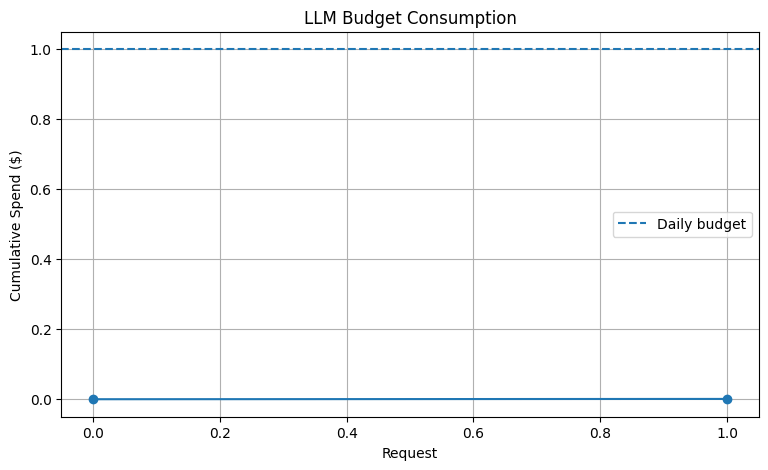

In [66]:
successful["cumulative_cost"] = (
    successful["cost"]
    .cumsum()
)

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    successful.index,
    successful["cumulative_cost"],
    marker="o"
)

plt.axhline(
    DAILY_BUDGET,
    linestyle="--",
    label="Daily budget"
)

plt.xlabel(
    "Request"
)

plt.ylabel(
    "Cumulative Spend ($)"
)

plt.title(
    "LLM Budget Consumption"
)

plt.legend()

plt.grid(True)

plt.show()

In [67]:
premium_model = models[
    models["model"] == "premium"
].iloc[0]

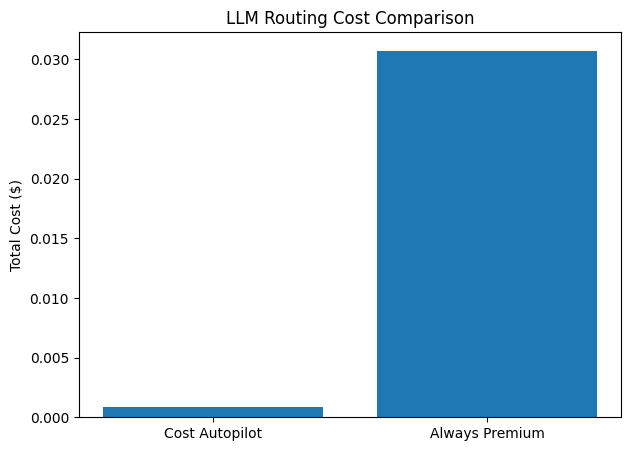

In [68]:
autopilot_cost = total_cost

always_premium_cost = 0.0
for prompt in demo_requests:
    input_tokens = estimate_tokens(prompt)
    output_tokens = estimate_output_tokens(prompt)
    always_premium_cost += calculate_cost(premium_model, input_tokens, output_tokens)

comparison = pd.DataFrame({
    "Strategy": [
        "Cost Autopilot",
        "Always Premium"
    ],

    "Cost": [
        autopilot_cost,
        always_premium_cost
    ]
})

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    comparison["Strategy"],
    comparison["Cost"]
)

plt.ylabel(
    "Total Cost ($)"
)

plt.title(
    "LLM Routing Cost Comparison"
)

plt.show()

In [69]:
complexity_cost = (
    successful
    .groupby("complexity")["cost"]
    .agg(
        requests="count",
        total_cost="sum",
        average_cost="mean"
    )
)

complexity_cost

,requests,total_cost,average_cost
complexity,,,
high,1,0.000856,0.000856
low,1,0.000040,0.000040


In [70]:
average_cost = successful[
    "cost"
].mean()

successful[
    "cost_anomaly"
] = (
    successful["cost"]
    >
    average_cost * 2
)

successful[
    [
        "prompt",
        "model",
        "cost",
        "cost_anomaly"
    ]
]

,prompt,model,cost,cost_anomaly
0,What is Python?,tiny,0.000040,False
1,\n Design an MLOps architecture for\n de...,standard,0.000856,False


In [71]:
cost_anomalies = successful[
    successful["cost_anomaly"]
]

cost_anomalies[
    [
        "prompt",
        "model",
        "cost"
    ]
]

,prompt,model,cost


In [72]:
successful[
    "cost_per_1k_tokens"
] = (
    successful["cost"]
    /
    (
        successful["input_tokens"]
        +
        successful["output_tokens"]
    )
    * 1000
)

successful[
    [
        "model",
        "complexity",
        "cost_per_1k_tokens"
    ]
]

,model,complexity,cost_per_1k_tokens
0,tiny,low,0.000391
1,standard,high,0.006687


In [73]:
savings = always_premium_cost - autopilot_cost
savings_percent = (savings / always_premium_cost) * 100 if always_premium_cost > 0 else 0

summary = {
    "total_requests":
        len(logs_df),

    "successful_requests":
        int(
            (
                logs_df["status"]
                == "SUCCESS"
            ).sum()
        ),

    "autopilot_cost":
        float(autopilot_cost),

    "always_premium_cost":
        float(always_premium_cost),

    "savings":
        float(savings),

    "savings_percent":
        float(savings_percent),

    "budget":
        DAILY_BUDGET,

    "remaining_budget":
        float(
            budget_remaining()
        )
}

summary

{'total_requests': 2,
 'successful_requests': 2,
 'autopilot_cost': 0.0008963,
 'always_premium_cost': 0.030728000000000002,
 'savings': 0.029831700000000003,
 'savings_percent': 97.08311637594377,
 'budget': 1.0,
 'remaining_budget': 0.9991037}

In [74]:
logs_df.to_csv(
    ARTIFACT_DIR /
    "llm_requests.csv",
    index=False
)

print(
    "Request logs saved."
)

Request logs saved.


In [75]:
report_path = (
    ARTIFACT_DIR /
    "cost_report.json"
)

with open(
    report_path,
    "w"
) as file:

    json.dump(
        summary,
        file,
        indent=4
    )

print(
    "Saved:",
    report_path
)

Saved: llm_cost_autopilot_artifacts/cost_report.json


In [76]:
def explain_route(prompt):

    route = route_request(
        prompt
    )

    print("Prompt:")
    print(prompt)

    print()

    print(
        "Complexity:",
        route["complexity"]
    )

    print(
        "Required quality:",
        route["required_quality"]
    )

    print(
        "Estimated input tokens:",
        route["input_tokens"]
    )

    print(
        "Estimated output tokens:",
        route["output_tokens"]
    )

    print(
        "Selected model:",
        route["model"]
    )

    print(
        "Estimated cost:",
        f"${route['estimated_cost']:.6f}"
    )

In [77]:
dashboard = (
    successful
    .groupby("model")
    .agg(
        requests=("model", "count"),
        total_tokens=("input_tokens", "sum"),
        total_cost=("cost", "sum"),
        avg_latency_ms=("latency_ms", "mean")
    )
    .reset_index()
)

dashboard

,model,requests,total_tokens,total_cost,avg_latency_ms
0,standard,1,28,0.000856,39.483118
1,tiny,1,3,0.000040,8.759925


In [78]:
def premium_cost(prompt):
    input_tokens = estimate_tokens(prompt)
    output_tokens = estimate_output_tokens(prompt)
    return calculate_cost(premium_model, input_tokens, output_tokens)

cheap = route_request(
    "What is Python?"
)

hard = route_request(
    """
    Design and analyze a distributed
    MLOps architecture with monitoring,
    security, and rollback.
    """
)

assert cheap["required_quality"] <= hard[
    "required_quality"
]

assert cheap["estimated_cost"] <= premium_cost(
    "What is Python?"
)

assert report_path.exists()

print(
    "✅ LLM Cost Autopilot works end-to-end."
)


✅ LLM Cost Autopilot works end-to-end.
